# TARGET 1 — Order Volume Forecast

**Goal:** Forecast the order count for the next 7 days for each region.  
**Approach:** `orders.parquet` + `weather.parquet` + `holidays.parquet`  
**Region-Day** aggregation → time series features → XGBoost model  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV

import xgboost as xgb

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(' All libraries loaded successfully!')
print(f'  XGBoost: {xgb.__version__}')


 All libraries loaded successfully!
  XGBoost: 3.0.0


## 1. Loading the Real Data

We load the actual project data directly from the parquet files:  
- `orders.parquet`: order_id, region, item_count, created_at, delivery_type, shipment_id  
- `weather.parquet`: timestamp, region, temperature, rainfall, wind_speed  
- `holidays.parquet`: date, event_name, region

**Fixes applied:**
- `Khankendi` is missing from orders.parquet (only 9 regions) — handled gracefully; REGIONS derived from orders data
- `weather.parquet` timestamp has timezone suffix (`+00:00`) — stripped during load
- `holidays.parquet` date is string format — converted to datetime
- Notebook previously referenced `'Baku'` region (does not exist) — fixed to `'Absheron'`
- `holidays_set` variable was undefined in forecast section — now properly built from parquet


In [2]:
# ─── Load Orders ──────────────────────────────────────────────────
orders_df = pd.read_parquet('orders.parquet')
orders_df['created_at'] = pd.to_datetime(orders_df['created_at'])

# Regions derived from actual data (9 regions in orders, Khankendi absent)
REGIONS = sorted(orders_df['region'].unique())

print(f" Orders: {len(orders_df):,} rows, {len(orders_df.columns)} columns")
print(f"   Date range: {orders_df['created_at'].min()} → {orders_df['created_at'].max()}")
print(f"   Regions ({len(REGIONS)}): {REGIONS}")

# ─── Load Weather ─────────────────────────────────────────────────
weather_df = pd.read_parquet('weather.parquet')
# Strip timezone suffix from timestamp (e.g. '2020-01-01 00:00:00+00:00')
weather_df['timestamp'] = pd.to_datetime(
    weather_df['timestamp'].astype(str).str.replace(r'\+00:00$', '', regex=True)
)
# Keep only regions present in orders
weather_df = weather_df[weather_df['region'].isin(REGIONS)]
print(f" Weather: {len(weather_df):,} rows | regions: {sorted(weather_df['region'].unique())}")

# ─── Load Holidays ────────────────────────────────────────────────
holidays_df = pd.read_parquet('holidays.parquet')
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
# Build holidays_set (set of date strings YYYY-MM-DD) for fast lookup
holidays_set = set(holidays_df['date'].dt.strftime('%Y-%m-%d'))
print(f" Holidays: {len(holidays_df)} rows | {min(holidays_set)} → {max(holidays_set)}")


 Orders: 110,000 rows, 8 columns
   Date range: 2020-01-01 00:49:03 → 2026-06-12 23:06:16
   Regions (10): ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
 Weather: 23,570 rows | regions: ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
 Holidays: 135 rows | 2020-01-01 → 2026-12-31


## 2. Feature Engineering

**Why these features?**  
- **Lag features:** Past orders are the strongest signal for forecasting the future  
- **Rolling averages:** Smooth out the trend and protect against short-term noise  
- **Time components:** Capture weekly/monthly seasonality  
- **Weather:** Rain and temperature change ordering behavior  
- **Holiday flags:** Critical for forecasting peaks


In [3]:
# ─── Daily aggregation ────────────────────────────────────────────
orders_df['date'] = orders_df['created_at'].dt.normalize()   # BUG 1 FIX

daily = (orders_df.groupby(['date', 'region'])
         .agg(order_count=('order_id', 'count'),
              avg_item_count=('item_count', 'mean'),
              express_ratio=('delivery_type', lambda x: (x == 'express').mean()))
         .reset_index())
daily['date'] = pd.to_datetime(daily['date'])

# ─── Weather aggregation ─────────────────────────────────────────
weather_df['date'] = weather_df['timestamp'].dt.normalize()  # BUG 2 FIX
weather_agg = (weather_df.groupby(['date', 'region'])
               .agg(temperature=('temperature', 'mean'),
                    rainfall=('rainfall', 'sum'),
                    wind_speed=('wind_speed', 'mean'))
               .reset_index())

daily = daily.merge(weather_agg, on=['date', 'region'], how='left')

# ─── Holiday flag ────────────────────────────────────────────────
daily['date_str']   = daily['date'].dt.strftime('%Y-%m-%d')
daily['is_holiday'] = daily['date_str'].isin(holidays_set).astype(int)
daily.drop(columns=['date_str'], inplace=True)

# ─── Time features ───────────────────────────────────────────────
daily['dayofweek']    = daily['date'].dt.dayofweek
daily['month']        = daily['date'].dt.month
daily['quarter']      = daily['date'].dt.quarter
daily['year']         = daily['date'].dt.year
daily['dayofyear']    = daily['date'].dt.dayofyear
daily['week']         = daily['date'].dt.isocalendar().week.astype(int)
daily['is_weekend']   = (daily['dayofweek'] >= 5).astype(int)
daily['is_month_end'] = daily['date'].dt.is_month_end.astype(int)
daily['sin_dow']      = np.sin(2 * np.pi * daily['dayofweek'] / 7)
daily['cos_dow']      = np.cos(2 * np.pi * daily['dayofweek'] / 7)
daily['sin_month']    = np.sin(2 * np.pi * daily['month'] / 12)
daily['cos_month']    = np.cos(2 * np.pi * daily['month'] / 12)
daily['trend']        = (daily['date'] - daily['date'].min()).dt.days

daily = daily.sort_values(['region', 'date']).reset_index(drop=True)

# ─── Lag features ────────────────────────────────────────────────
for lag in [1, 2, 3, 7, 14, 21, 28]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for lag in [364, 365, 366]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

# ─── Rolling features ────────────────────────────────────────────
for window in [3, 7, 14, 28]:
    daily[f'rolling_mean_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean()))
    daily[f'rolling_std_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0)))

daily['rolling_mean_365'] = (
    daily.groupby('region')['order_count']
    .transform(lambda x: x.shift(1).rolling(365, min_periods=30).mean()))

daily['same_dow_last_week'] = (
    daily.groupby(['region', 'dayofweek'])['order_count'].shift(1))

# ─── Holiday proximity ───────────────────────────────────────────
import bisect
hol_sorted = sorted(holidays_df['date'].tolist())
hol_set    = set(hol_sorted)

def days_to_nearest_holiday(d):
    idx  = bisect.bisect_left(hol_sorted, d)
    best = 999
    if idx < len(hol_sorted):
        best = min(best, (hol_sorted[idx] - d).days)
    if idx > 0:
        best = min(best, abs((d - hol_sorted[idx - 1]).days))
    return best

daily['days_to_holiday']  = daily['date'].apply(days_to_nearest_holiday)
daily['is_holiday_eve']   = daily['date'].apply(
    lambda d: int((d + pd.Timedelta(days=1)) in hol_set))
daily['is_holiday_after'] = daily['date'].apply(
    lambda d: int((d - pd.Timedelta(days=1)) in hol_set))

# ─── Region encoding + weather fill ─────────────────────────────
le = LabelEncoder()
daily['region_enc'] = le.fit_transform(daily['region'])

for col in ['temperature', 'rainfall', 'wind_speed']:
    daily[col] = daily.groupby(['region', 'month'])[col].transform(
        lambda x: x.fillna(x.median()))
    daily[col] = daily[col].fillna(daily[col].median())

daily_clean = daily.dropna().copy()

print(f"Feature engineering complete.")
print(f"Rows after dropna : {len(daily_clean):,}")
print(f"Total columns     : {len(daily_clean.columns)}")

Feature engineering complete.
Rows after dropna : 15,792
Total columns     : 46


## 3. Exploratory Data Analysis (EDA)

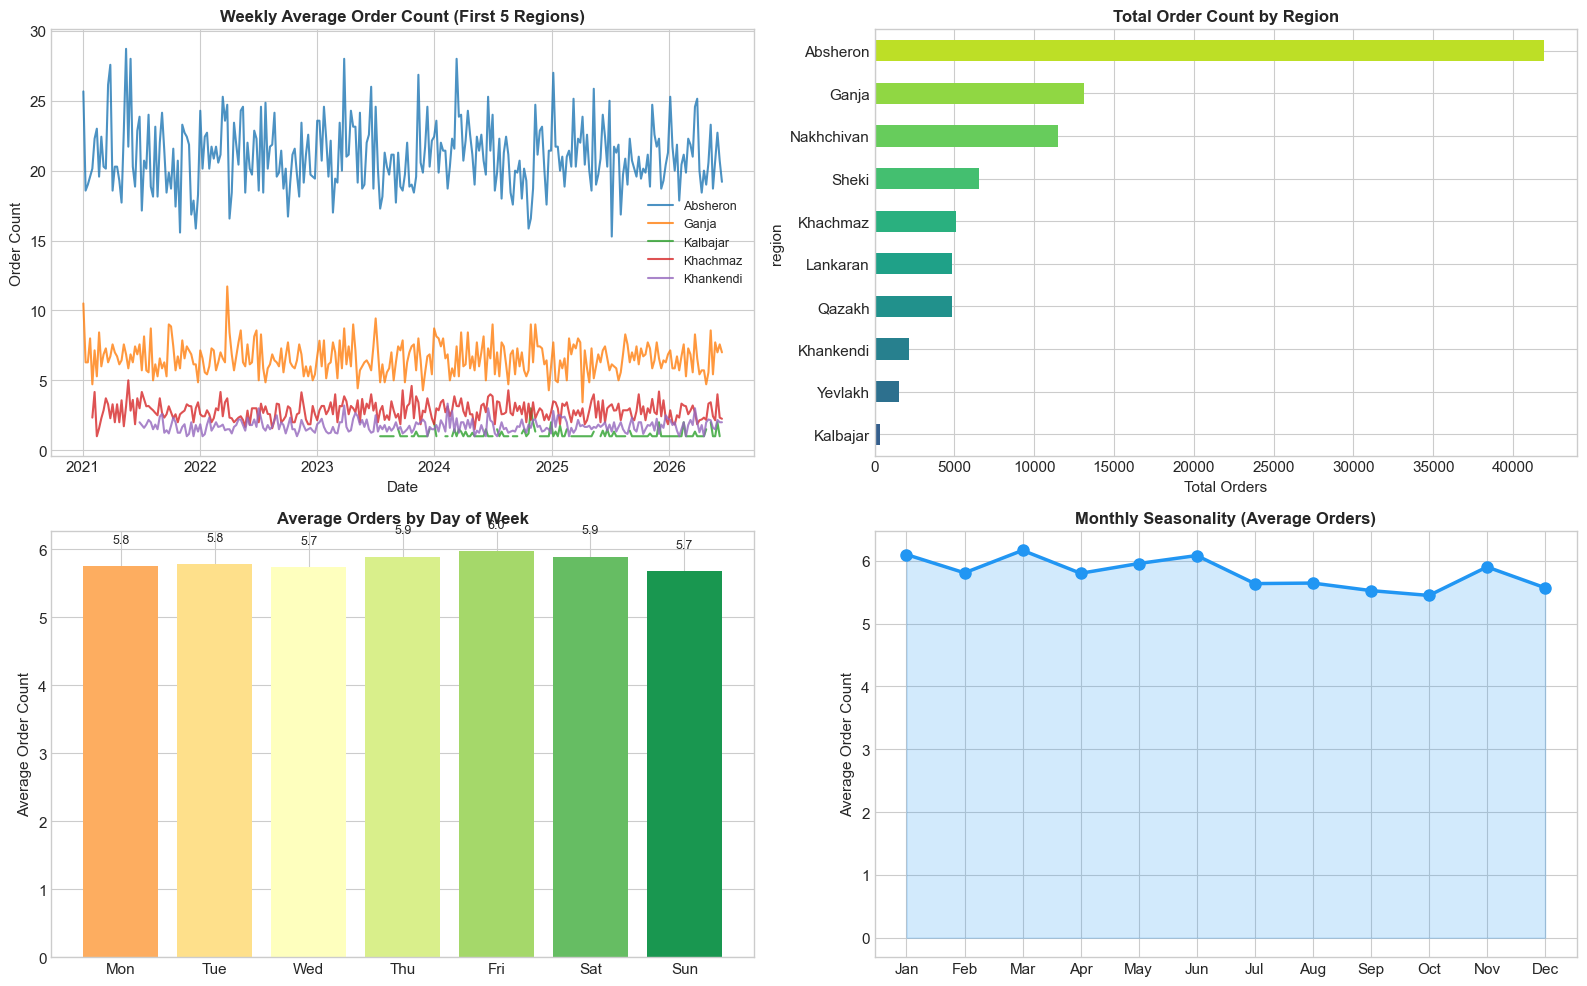

 EDA visualization complete!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Daily order count by region (weekly resample)
ax = axes[0, 0]
for region in REGIONS[:5]:
    sub = daily_clean[daily_clean['region'] == region].set_index('date')['order_count']
    sub_weekly = sub.resample('W').mean()
    ax.plot(sub_weekly.index, sub_weekly.values, label=region, alpha=0.8, linewidth=1.5)
ax.set_title('Weekly Average Order Count (First 5 Regions)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Order Count')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Total order share by region
ax = axes[0, 1]
region_totals = daily_clean.groupby('region')['order_count'].sum().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(region_totals)))
region_totals.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Total Order Count by Region', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Orders')

# Plot 3: Day-of-week effect
ax = axes[1, 0]
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_means = daily_clean.groupby('dayofweek')['order_count'].mean()
bars = ax.bar(dow_labels, dow_means.values, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 7)))
ax.set_title('Average Orders by Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Order Count')
for bar, val in zip(bars, dow_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Monthly seasonality
ax = axes[1, 1]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_means = daily_clean.groupby('month')['order_count'].mean()
ax.plot(range(1, 13), month_means.values, 'o-', linewidth=2.5,
        markersize=8, color='#2196F3')
ax.fill_between(range(1, 13), month_means.values, alpha=0.2, color='#2196F3')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Monthly Seasonality (Average Orders)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Order Count')

plt.tight_layout()
plt.show()
print(" EDA visualization complete!")


## 4. Train/Test Split

**Why a time-based split?**  
To avoid leaking the future into the past in a time series, we hold out the last 60 days as the test set.  
This mirrors a real deployment scenario.


In [5]:
daily = daily.sort_values(['region', 'date']).reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 21, 28]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for lag in [364, 365, 366]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for window in [3, 7, 14, 28]:
    daily[f'rolling_mean_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean()))
    daily[f'rolling_std_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0)))

daily['rolling_mean_365'] = (
    daily.groupby('region')['order_count']
    .transform(lambda x: x.shift(1).rolling(365, min_periods=30).mean()))

daily['same_dow_last_week'] = daily.groupby(['region', 'dayofweek'])['order_count'].shift(1)

import bisect
hol_sorted = sorted(holidays_df['date'].tolist())
hol_set    = set(hol_sorted)

def days_to_nearest_holiday(d):
    idx  = bisect.bisect_left(hol_sorted, d)
    best = 999
    if idx < len(hol_sorted):
        best = min(best, (hol_sorted[idx] - d).days)
    if idx > 0:
        best = min(best, abs((d - hol_sorted[idx - 1]).days))
    return best

daily['days_to_holiday']  = daily['date'].apply(days_to_nearest_holiday)
daily['is_holiday_eve']   = daily['date'].apply(
    lambda d: int((d + pd.Timedelta(days=1)) in hol_set))
daily['is_holiday_after'] = daily['date'].apply(
    lambda d: int((d - pd.Timedelta(days=1)) in hol_set))

le = LabelEncoder()
daily['region_enc'] = le.fit_transform(daily['region'])

for col in ['temperature', 'rainfall', 'wind_speed']:
    daily[col] = daily.groupby(['region', 'month'])[col].transform(
        lambda x: x.fillna(x.median()))
    daily[col] = daily[col].fillna(daily[col].median())

daily_clean = daily.dropna().copy()
print(f" Feature engineering complete!")
print(f"   Rows after dropna: {len(daily_clean):,}")
print(f"   Columns: {len(daily_clean.columns)}")

 Feature engineering complete!
   Rows after dropna: 15,792
   Columns: 46


In [6]:
FEATURE_COLS = [
    # Time
    'dayofweek','month','quarter','year','dayofyear','week',
    'is_weekend','is_month_end','is_holiday','trend',
    'sin_dow','cos_dow','sin_month','cos_month',
    # Lag — standart
    'lag_1','lag_2','lag_3','lag_7','lag_14','lag_21','lag_28',
    # Lag — keçən il
    'lag_364','lag_365','lag_366',
    # Rolling — standart
    'rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_28',
    'rolling_std_3','rolling_std_7','rolling_std_14','rolling_std_28',
    # Rolling — illik
    'rolling_mean_365',
    'same_dow_last_week',
    # Holiday proximity
    'days_to_holiday','is_holiday_eve','is_holiday_after',
    # Weather
    'temperature','rainfall','wind_speed',
    # Other
    'avg_item_count','express_ratio','region_enc',
]

TARGET_COL  = 'order_count'
cutoff_date = pd.Timestamp('2026-04-13')

train_df = daily_clean[daily_clean['date'] < cutoff_date].copy()
test_df  = daily_clean[daily_clean['date'] >= cutoff_date].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f" Train: {len(X_train):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f" Test : {len(X_test):,} rows  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f" Features: {len(FEATURE_COLS)}")
print(f" Target mean={y_train.mean():.2f}, std={y_train.std():.2f}")

 Train: 15,286 rows  (2021-01-01 → 2026-04-12)
 Test : 506 rows  (2026-04-13 → 2026-06-12)
 Features: 43
 Target mean=5.82, std=6.52


## 5. ML Model Tuning and Training

**Model:** XGBoost Regressor — default parameters, then GridSearchCV hyperparameter tuning (cv=10).  


In [7]:
# ─── Unified evaluate_model (train+test, no refit) ───────────────────────
results     = {}
best_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = np.maximum(model.predict(X_tr), 0)
    pred_te = np.maximum(model.predict(X_te), 0)
    res = {
        'Train_MAE':   mean_absolute_error(y_tr, pred_tr),
        'Train_RMSE':  np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'Train_R2':    r2_score(y_tr, pred_tr),
        'Test_MAE':    mean_absolute_error(y_te, pred_te),
        'Test_RMSE':   np.sqrt(mean_squared_error(y_te, pred_te)),
        'Test_R2':     r2_score(y_te, pred_te),
        'MAPE':        np.mean(np.abs((y_te - pred_te) / (y_te + 1e-6))) * 100,
        'predictions': pred_te,
        'model_obj':   model,
    }
    return res

In [8]:
# ═══════════════════════════════════════════════════════════════════
# MODEL: XGBoost Regressor — Default Parameters
# ═══════════════════════════════════════════════════════════════════
print("Model: XGBoost Regressor (default parameters)")

xgb_default = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror')
xgb_default.fit(X_train, y_train)

results['XGBoost_Default']     = evaluate_model('XGBoost_Default', xgb_default, X_train, y_train, X_test, y_test)
best_models['XGBoost_Default'] = xgb_default

r = results['XGBoost_Default']
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")


Model: XGBoost Regressor (default parameters)
    Train → MAE=0.638  RMSE=0.902  R²=0.9809
    Test  → MAE=1.206  RMSE=2.093  R²=0.8916



In [9]:
# ═══════════════════════════════════════════════════════════════════
# MODEL: XGBoost Regressor — Hyperparameter Tuning (GridSearchCV)
# ═══════════════════════════════════════════════════════════════════
print("Model: XGBoost Regressor (hyperparameter tuning)")

xgb_param_grid = {
    'n_estimators':     [300],   
    'learning_rate':    [0.07],
    'max_depth':        [3],   
    'subsample':        [0.7],   
    'colsample_bytree': [0.7],   
    'min_child_weight': [10],     
    'reg_alpha':        [0],   
    'reg_lambda':       [0.0],  
    'gamma':            [3],   
}

CV_FOLDS = 10   # number of GridSearchCV folds
total_combinations = int(np.prod([len(v) for v in xgb_param_grid.values()]))
print(f"    GridSearchCV Fits: {total_combinations * CV_FOLDS} fits\n")

xgb_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror'),
    xgb_param_grid, cv=CV_FOLDS, scoring='r2', n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

results['XGBoost_Tuned']     = evaluate_model('XGBoost_Tuned', best_xgb, X_train, y_train, X_test, y_test)
best_models['XGBoost_Tuned'] = best_xgb

r = results['XGBoost_Tuned']
print(f"    Best params : {xgb_search.best_params_}")
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")


Model: XGBoost Regressor (hyperparameter tuning)
    GridSearchCV Fits: 10 fits

    Best params : {'colsample_bytree': 0.7, 'gamma': 3, 'learning_rate': 0.07, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 0.0, 'subsample': 0.7}
    Train → MAE=1.234  RMSE=1.823  R²=0.9217
    Test  → MAE=1.356  RMSE=2.144  R²=0.8862



## 6. Save Best Model with joblib


In [10]:
import joblib, os

os.makedirs("models", exist_ok=True)

best_key       = 'XGBoost_Tuned'
best_model_obj = best_models[best_key]

model_path = f"models/target1_{best_key}_best.joblib"
joblib.dump(best_model_obj, model_path)

print(f"Best model: {best_key}")
print(f"Saved to: {model_path}")


Best model: XGBoost_Tuned
Saved to: models/target1_XGBoost_Tuned_best.joblib


## 7. 7-Day Forecast (by Region)


In [11]:
def recursive_forecast_7day(model, daily_clean, region, future_dates,
                             feature_cols, holidays_set, hol_sorted, weather_df, le,
                             train_df):

    reg_hist = (daily_clean[daily_clean['region'] == region]
                .sort_values('date').copy())

    # Guard: if no history exists for this region, return zeros
    if len(reg_hist) == 0:
        print(f"  WARNING: no history for region '{region}', returning zeros.")
        return [0.0] * len(future_dates)

    series  = reg_hist.set_index('date')['order_count'].astype(float).copy()
    global_min_date = daily_clean['date'].min()

    # Safe lookup: returns value from series if date exists, else fallback
    def get_value(s, date):
        if date in s.index:
            return float(s[date])
        if len(s) == 0:
            return 0.0
        return float(s.iloc[-1])

    # Precompute region-level averages from training data once
    reg_tr = train_df[train_df['region'] == region]
    avg_item_count = float(reg_tr['avg_item_count'].mean()) if len(reg_tr) > 0 else 1.0
    express_ratio  = float(reg_tr['express_ratio'].mean())  if len(reg_tr) > 0 else 0.0

    hol_set = set(hol_sorted)

    preds = []
    for fdate in future_dates:

        row = {
            'dayofweek':        fdate.dayofweek,
            'month':            fdate.month,
            'quarter':          fdate.quarter,
            'year':             fdate.year,
            'dayofyear':        fdate.dayofyear,
            'week':             int(fdate.isocalendar().week),
            'is_weekend':       int(fdate.dayofweek >= 5),
            'is_month_end':     int(fdate.is_month_end),
            'is_holiday':       int(fdate.strftime('%Y-%m-%d') in holidays_set),
            'trend':            (fdate - global_min_date).days,
            'sin_dow':          np.sin(2 * np.pi * fdate.dayofweek / 7),
            'cos_dow':          np.cos(2 * np.pi * fdate.dayofweek / 7),
            'sin_month':        np.sin(2 * np.pi * fdate.month / 12),
            'cos_month':        np.cos(2 * np.pi * fdate.month / 12),
            'region_enc':       int(le.transform([region])[0]),
            'days_to_holiday':  days_to_nearest_holiday(fdate),
            'is_holiday_eve':   int((fdate + pd.Timedelta(days=1)) in hol_set),
            'is_holiday_after': int((fdate - pd.Timedelta(days=1)) in hol_set),
            'avg_item_count':   avg_item_count,
            'express_ratio':    express_ratio,
        }

        # Lag features — series already contains previously predicted days
        for lag in [1, 2, 3, 7, 14, 21, 28, 364, 365, 366]:
            past = fdate - pd.Timedelta(days=lag)
            row[f'lag_{lag}'] = get_value(series, past)

        # Rolling features over the live series (includes predicted days)
        for win in [3, 7, 14, 28]:
            tail = series.iloc[-win:] if len(series) >= win else series
            row[f'rolling_mean_{win}'] = float(tail.mean()) if len(tail) > 0 else 0.0
            row[f'rolling_std_{win}']  = float(tail.std())  if len(tail) > 1 else 0.0

        tail_365 = series.iloc[-365:] if len(series) >= 365 else series
        row['rolling_mean_365'] = float(tail_365.mean()) if len(tail_365) > 0 else 0.0

        # Same day of week last week
        same_dow = fdate - pd.Timedelta(weeks=1)
        row['same_dow_last_week'] = get_value(series, same_dow)

        # Weather: historical monthly average for this region
        sw = weather_df[
            (weather_df['timestamp'].dt.month == fdate.month) &
            (weather_df['region'] == region)
        ]
        row['temperature'] = float(sw['temperature'].mean()) if len(sw) > 0 else 15.0
        row['rainfall']    = float(sw['rainfall'].mean())    if len(sw) > 0 else 2.0
        row['wind_speed']  = float(sw['wind_speed'].mean())  if len(sw) > 0 else 15.0

        # Predict
        X_row = pd.DataFrame([row])[feature_cols]
        yhat  = float(max(0.0, model.predict(X_row)[0]))
        preds.append(yhat)

        # Append prediction to series so next day can use it as a lag
        series.loc[fdate] = yhat

    return preds

In [12]:
last_date    = daily_clean['date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=7, freq='D')

print(f"Generating 7-day recursive forecast with model: {best_key}")
print(f"Forecast window: {future_dates[0].date()} to {future_dates[-1].date()}\n")

forecast_records = []
for region in REGIONS:
    day_preds = recursive_forecast_7day(
        model        = best_model_obj,
        daily_clean  = daily_clean,
        region       = region,
        future_dates = future_dates,
        feature_cols = FEATURE_COLS,
        holidays_set = holidays_set,
        hol_sorted   = hol_sorted,
        weather_df   = weather_df,
        le           = le,
        train_df     = train_df,
    )
    for fdate, pred in zip(future_dates, day_preds):
        forecast_records.append({
            'Region':            region,
            'Date':              fdate.date(),
            'Day of Week':       ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][fdate.dayofweek],
            'Forecast (Orders)': int(round(pred)),
        })

forecast_df = pd.DataFrame(forecast_records)
pivot = forecast_df.pivot(index='Region', columns='Date', values='Forecast (Orders)')
pivot['TOTAL (7 days)'] = pivot.sum(axis=1)
pivot = pivot.sort_values('TOTAL (7 days)', ascending=False)

print("=" * 80)
print(f"TARGET 1  --  {future_dates[0].date()} to {future_dates[-1].date()}  (7-Day Recursive Forecast)")
print(f"Model: {best_key}  |  Test MAE: {results[best_key]['Test_MAE']:.3f}  |  Test R2: {results[best_key]['Test_R2']:.4f}")
print("=" * 80)
print(pivot.to_string())
print("=" * 80)
print(f"Total forecast (all regions, 7 days): {pivot['TOTAL (7 days)'].sum():,} orders")


Generating 7-day recursive forecast with model: XGBoost_Tuned
Forecast window: 2026-06-13 to 2026-06-19

TARGET 1  --  2026-06-13 to 2026-06-19  (7-Day Recursive Forecast)
Model: XGBoost_Tuned  |  Test MAE: 1.356  |  Test R2: 0.8862
Date        2026-06-13  2026-06-14  2026-06-15  2026-06-16  2026-06-17  2026-06-18  2026-06-19  TOTAL (7 days)
Region                                                                                                        
Absheron            23          25          26          24          22          22          22             164
Ganja                8           9           9           9           8           8           8              59
Nakhchivan           7           8           8           8           7           7           7              52
Sheki                5           5           5           7           6           6           6              40
Qazakh               5           6           6           5           5           5           5       

### 7-day forecast — JSON output


In [13]:
import json

json_records = []
for region in REGIONS:
    reg_rows = forecast_df[forecast_df['Region'] == region].sort_values('Date')
    json_records.append({
        "region": region,
        "model": best_key,
        "forecast": [
            {"date": str(row['Date']), "day_of_week": row['Day of Week'], "orders": int(row['Forecast (Orders)'])}
            for _, row in reg_rows.iterrows()
        ],
        "total_7day_orders": int(reg_rows['Forecast (Orders)'].sum()),
    })

forecast_json = json.dumps(json_records, indent=2, ensure_ascii=False)

with open("target1_7day_forecast.json", "w", encoding="utf-8") as f:
    f.write(forecast_json)

print(f"Saved 7-day forecast for {len(json_records)} regions to target1_7day_forecast.json")
print(forecast_json[:800])


Saved 7-day forecast for 10 regions to target1_7day_forecast.json
[
  {
    "region": "Absheron",
    "model": "XGBoost_Tuned",
    "forecast": [
      {
        "date": "2026-06-13",
        "day_of_week": "Sat",
        "orders": 23
      },
      {
        "date": "2026-06-14",
        "day_of_week": "Sun",
        "orders": 25
      },
      {
        "date": "2026-06-15",
        "day_of_week": "Mon",
        "orders": 26
      },
      {
        "date": "2026-06-16",
        "day_of_week": "Tue",
        "orders": 24
      },
      {
        "date": "2026-06-17",
        "day_of_week": "Wed",
        "orders": 22
      },
      {
        "date": "2026-06-18",
        "day_of_week": "Thu",
        "orders": 22
      },
      {
        "date": "2026-06-19",
        "day_of_week": "Fri",
        "orders": 22
      }
    ],
    "total_7day_orders": 164
